# 01 Exploratory Data Analysis (EDA)
Notebook này tập trung vào khám phá dữ liệu trước khi xây dựng SVAR/SARIMA.

Mục tiêu:
- Quan sát hình dạng phân phối và mức biến động của NASDAQ-100.
- So sánh động lực giữa NASDAQ-100 và lãi suất FEDFUNDS theo thời gian.
- Kiểm tra tương quan ban đầu giữa các biến vĩ mô và biến thị trường.
- Ghi nhận các dấu hiệu cấu trúc có thể ảnh hưởng đến mô hình hóa ở các bước sau.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="talk")

ROOT = Path.cwd().resolve().parent
RAW_DIR = ROOT / "data" / "raw"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1) Chuẩn bị dữ liệu cho EDA

Dữ liệu thô được lấy trực tiếp từ FRED. Để so sánh vĩ mô với thị trường ở cùng tần suất, NASDAQ-100 sẽ được hạ tần suất về tháng (lấy điểm cuối tháng), sau đó gộp với CPIAUCSL và FEDFUNDS.

In [2]:
def load_fred_series(path: Path, value_col: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.rename(columns={"observation_date": "date", value_col: value_col.lower()})
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df[value_col.lower()] = pd.to_numeric(df[value_col.lower()], errors="coerce")
    df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
    return df

ndx_daily = load_fred_series(RAW_DIR / "NASDAQ100.csv", "NASDAQ100")
cpi_monthly = load_fred_series(RAW_DIR / "CPIAUCSL.csv", "CPIAUCSL")
ffr_monthly = load_fred_series(RAW_DIR / "FEDFUNDS.csv", "FEDFUNDS")

ndx_monthly = (
    ndx_daily.set_index("date")
    .resample("MS")
    .last()
    .rename(columns={"nasdaq100": "ndx"})
    .reset_index()
)

eda_df = ndx_monthly.merge(cpi_monthly, on="date", how="inner")
eda_df = eda_df.merge(ffr_monthly, on="date", how="inner")
eda_df = eda_df.rename(columns={"cpiaucsl": "cpi", "fedfunds": "ffr"})
eda_df = eda_df[(eda_df["date"] >= "1986-01-01") & (eda_df["date"] <= "2026-04-01")]

eda_df["ndx_log_return"] = np.log(eda_df["ndx"]).diff()
eda_df["cpi_yoy"] = eda_df["cpi"].pct_change(12) * 100
eda_df["ffr_diff"] = eda_df["ffr"].diff()

print("EDA dataset shape:", eda_df.shape)
print("Date range:", eda_df["date"].min().date(), "->", eda_df["date"].max().date())
eda_df.head()

EDA dataset shape: (484, 7)
Date range: 1986-01-01 -> 2026-04-01


,date,ndx,cpi,ffr,ndx_log_return,cpi_yoy,ffr_diff
0,1986-01-01,132.93,109.9,8.14,NaN,NaN,NaN
1,1986-02-01,140.43,109.7,7.86,0.054886,NaN,-0.28
2,1986-03-01,148.86,109.1,7.48,0.058297,NaN,-0.38
3,1986-04-01,154.91,108.7,6.99,0.039838,NaN,-0.49
4,1986-05-01,163.16,109.0,6.85,0.051887,NaN,-0.14


## 2) Thống kê mô tả và tương quan ban đầu

Bảng dưới đây cho thấy phân bố cơ bản của các biến mức và biến biến đổi.

In [3]:
summary_stats = eda_df[["ndx", "cpi", "ffr", "ndx_log_return", "cpi_yoy", "ffr_diff"]].describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
ndx,484.0,4250.980496,5777.076985,132.930000,606.962500,1777.145000,4590.000000,27452.120000
cpi,483.0,201.678580,57.382230,108.700000,154.850000,199.400000,238.057000,332.407000
ffr,484.0,3.349938,2.645442,0.050000,0.407500,3.255000,5.330000,9.850000
ndx_log_return,483.0,0.011036,0.068364,-0.314344,-0.022109,0.018333,0.050003,0.222993
cpi_yoy,471.0,2.814705,1.591355,-1.958761,1.811176,2.698962,3.472903,8.979361
ffr_diff,483.0,-0.009317,0.197079,-0.960000,-0.040000,0.000000,0.050000,0.870000


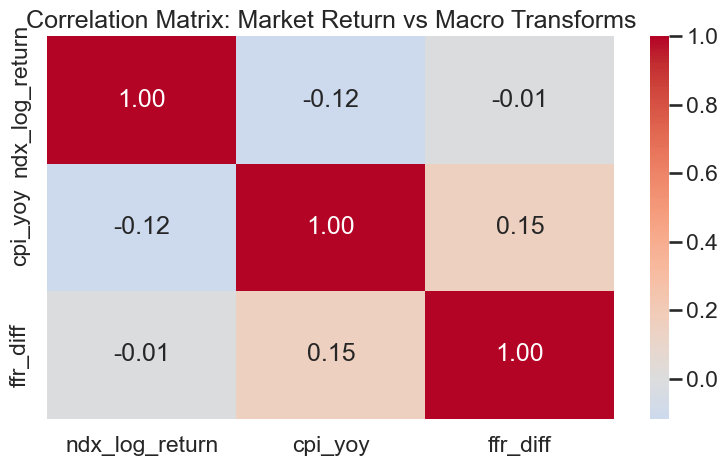

In [4]:
corr_df = eda_df[["ndx_log_return", "cpi_yoy", "ffr_diff"]].dropna().corr()
plt.figure(figsize=(8, 5))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Market Return vs Macro Transforms")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_correlation_heatmap.png", dpi=200)
plt.show()

**Nhận định và Phân tích tương quan:**
- Dựa trên ma trận tương quan (heatmap), mối quan hệ tuyến tính đồng thời (contemporaneous correlation) giữa lợi suất NASDAQ-100 với mức thay đổi lạm phát (cpi_yoy) và lãi suất (ffr_diff) nhìn chung là rất yếu (gần như bằng 0).
- Sự thiếu vắng tương quan mạnh trong cùng kỳ chứng tỏ rằng thị trường chứng khoán không đơn thuần phản ứng tuyến tính với mức thay đổi lãi suất gốc ngay lập tức, mà bị chi phối mạnh bởi yếu tố kỳ vọng, các xung kích trễ và hiệu ứng thông tin của Fed (như Bauer & Swanson đã chỉ ra).
- Kết quả này củng cố quan điểm phải áp dụng hệ thống SVAR với độ trễ (lags) hợp lý thay vì chỉ quy hồi tuyến tính tĩnh, để phân tách các cú sốc cấu trúc.

## 3) Rolling Mean/Std của NASDAQ-100

Biểu đồ rolling giúp quan sát các pha chuyển chế độ biến động theo thời gian.

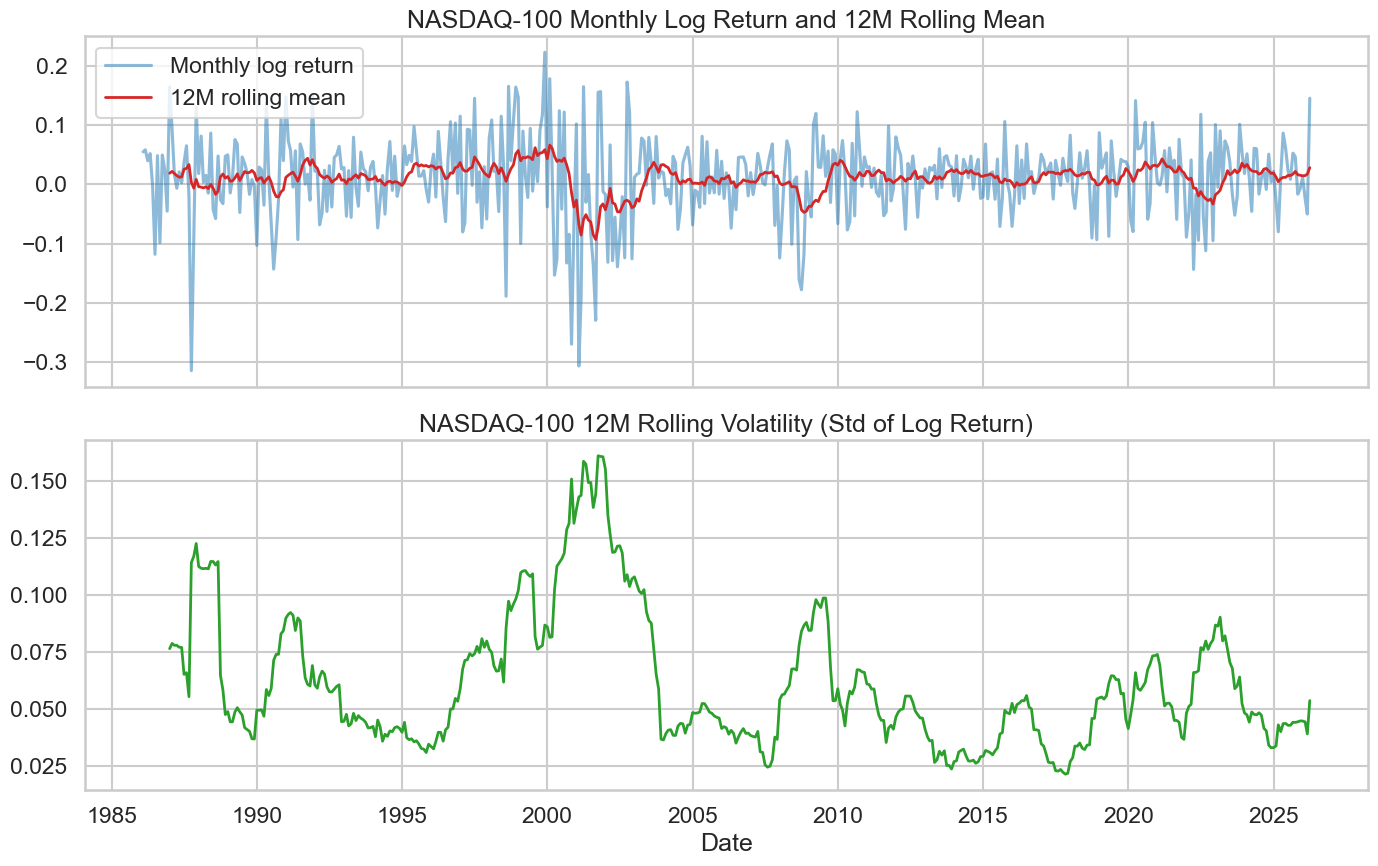

In [5]:
roll_window = 12
roll_df = eda_df.set_index("date").copy()
roll_df["roll_mean_return"] = roll_df["ndx_log_return"].rolling(roll_window).mean()
roll_df["roll_std_return"] = roll_df["ndx_log_return"].rolling(roll_window).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(roll_df.index, roll_df["ndx_log_return"], color="#1f77b4", alpha=0.5, label="Monthly log return")
axes[0].plot(roll_df.index, roll_df["roll_mean_return"], color="#d62728", linewidth=2, label="12M rolling mean")
axes[0].set_title("NASDAQ-100 Monthly Log Return and 12M Rolling Mean")
axes[0].legend(loc="upper left")

axes[1].plot(roll_df.index, roll_df["roll_std_return"], color="#2ca02c", linewidth=2)
axes[1].set_title("NASDAQ-100 12M Rolling Volatility (Std of Log Return)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_rolling_mean_std.png", dpi=200)
plt.show()

**Nhận định và Phân tích độ trôi:**
- Lợi suất trung bình trượt 12 tháng (rolling mean) dao động mạnh qua các chu kỳ, thường giảm sâu âm ở những cú sốc vĩ mô (dot-com, GFC 2008, 2022) và phục hồi mạnh mẽ sau đó.
- Độ bay hơi trượt (rolling volatility) không duy trì ở mức hằng số mà tăng vọt thành các cụm (volatility clustering) sát vào các quãng khủng hoảng.
- Điều này chứng minh chuỗi NDX return không hoàn toàn dừng (stationary) nếu đánh giá theo phương sai, ủng hộ cách tiếp cận phân rã và việc đưa các số hạng trung bình động (MA) hoặc các yếu tố can thiệp (exogenous) vào mô hình SARIMAX.

## 4) Phân phối lợi suất: Histogram và Q-Q Plot

Mục tiêu là kiểm tra mức độ lệch khỏi chuẩn của lợi suất log theo tháng.

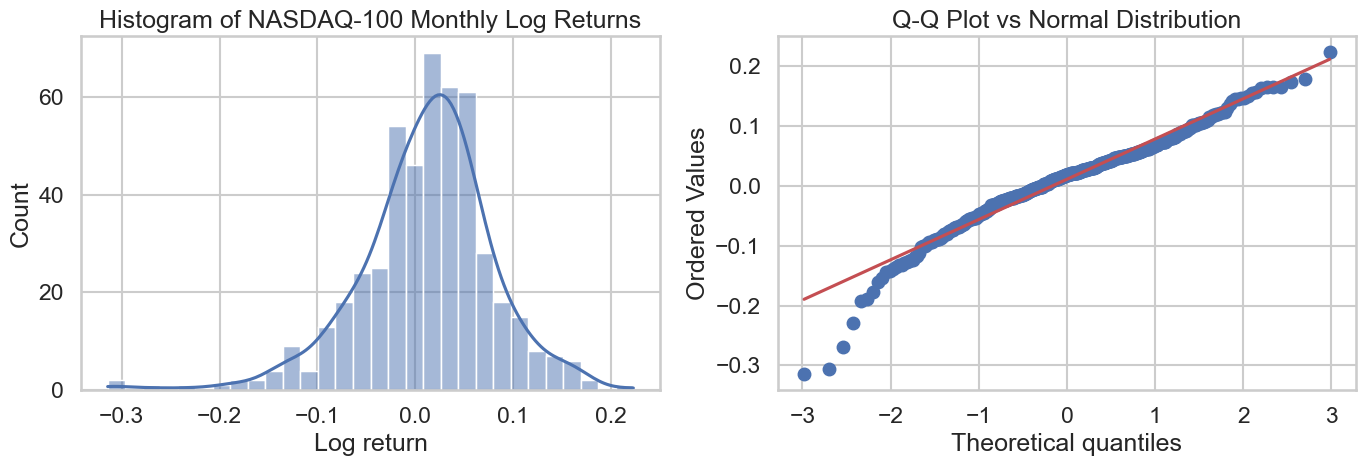

In [6]:
ret = eda_df["ndx_log_return"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(ret, bins=30, kde=True, ax=axes[0], color="#4c72b0")
axes[0].set_title("Histogram of NASDAQ-100 Monthly Log Returns")
axes[0].set_xlabel("Log return")

stats.probplot(ret, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot vs Normal Distribution")

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_hist_qqplot.png", dpi=200)
plt.show()

**Nhận định và Phân tích phân phối:**
- Biểu đồ Histogram và Q-Q plot chỉ ra phân phối lợi suất của NASDAQ-100 có đuôi rất dày (fat tails/leptokurtic) ở cả hai đầu, khác đáng kể so với phân phối chuẩn lý thuyết (quần thể điểm ở Q-Q plot chệch mạnh khỏi đường thẳng đỏ ở các vị trí cực trị).
- Nghĩa là các đợt bùng nổ lợi nhuận hoặc các cú sụt giảm mạnh (tai nạn thiên nga đen, bong bóng nổ) xảy ra với tần suất cao hơn thông thường.
- Ở các notebook sau, mô hình SARIMA cần kiểm tra kỹ residual diagnostics (Ljung-Box) để đảm bảo không bỏ sót thông tin từ các cú sốc cực đại.

## 5) Dual-axis: NASDAQ-100 và FEDFUNDS theo thời gian

Biểu đồ hai trục giúp đối chiếu các pha chính sách tiền tệ với quỹ đạo định giá chỉ số công nghệ.

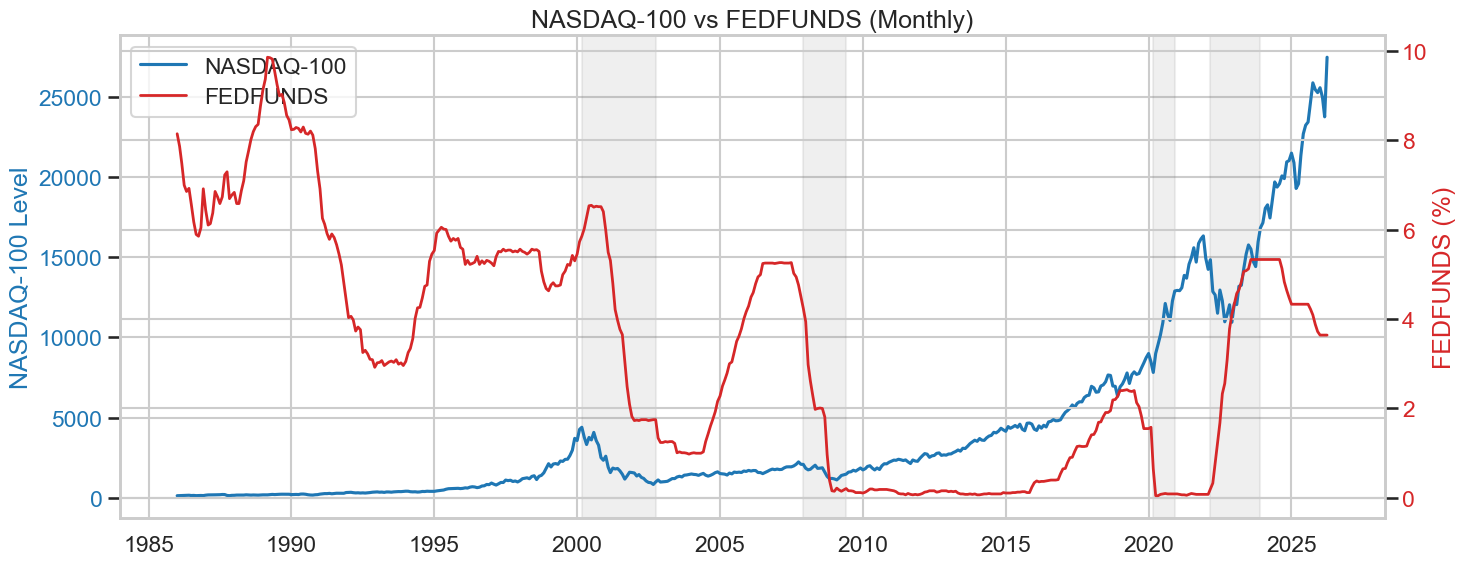

In [7]:
plot_df = eda_df.set_index("date")
fig, ax1 = plt.subplots(figsize=(15, 6))

line1 = ax1.plot(plot_df.index, plot_df["ndx"], color="#1f77b4", label="NASDAQ-100")
ax1.set_ylabel("NASDAQ-100 Level", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")

ax2 = ax1.twinx()
line2 = ax2.plot(plot_df.index, plot_df["ffr"], color="#d62728", linewidth=2, label="FEDFUNDS")
ax2.set_ylabel("FEDFUNDS (%)", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

event_windows = [
    ("2000-03-01", "2002-10-01", "Dot-com bust"),
    ("2007-12-01", "2009-06-01", "Global Financial Crisis"),
    ("2020-03-01", "2020-12-01", "COVID shock"),
    ("2022-03-01", "2023-12-01", "Rate hiking cycle"),
]
for start, end, _ in event_windows:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="gray", alpha=0.12)

all_lines = line1 + line2
labels = [l.get_label() for l in all_lines]
ax1.legend(all_lines, labels, loc="upper left")
ax1.set_title("NASDAQ-100 vs FEDFUNDS (Monthly)")

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_dual_axis_ndx_ffr.png", dpi=200)
plt.show()

**Nhận định và Phân tích tương tác lịch sử (Dual-axis):**
- Biểu đồ minh họa rõ ràng hiện tượng "đỉnh rủi ro": Trong đợt bùng nổ dot-com (2000) và chu kỳ lạm phát gần đây (2022), sự gia tăng nhanh của lãi suất FEDFUNDS dường như tạo áp lực dẫn tới đợt sụt giảm thị trường.
- Tuy nhiên, trong pha 2004-2006, FEDFUNDS tăng nhưng NASDAQ-100 vẫn củng cố nền giá. Điều này chỉ ra rằng tác động của lãi suất phụ thuộc vào bối cảnh vĩ mô nền tảng (nếu lãi suất tăng do kinh tế cực kỳ dồi dào sức cầu thì chứng khoán chưa chắc đã sập).
- Nhận diện sự bất đối xứng và độ trễ này chính là lý do Impulse Response Function (IRF) của SVAR cần thiết để cô lập "cú sốc chính sách thuần túy" ra khỏi các đợt điều chỉnh lãi suất phản ứng theo chu kỳ.

## 6) Kết luận EDA

Tóm tắt các điểm chuyển bị cho giai đoạn mô hình hóa:
- **Chuỗi thị trường phi tuyến tính và bộc lộ độ biến động theo cụm (Volatility Clustering):** Củng cố tính cần thiết của việc chia dữ liệu và phân rã các tính chất nội tại của chỉ số.
- **Mối liên hệ thị trường-vĩ mô không đơn giản là đồng thời:** SVAR sẽ khai thác các độ trễ chéo (lags) để tìm hướng nhân quả, còn SARIMAX sẽ thừa hưởng thông tin để làm các biến ngoại sinh.
- **Xử lý dữ liệu:** Chuỗi đã được định hình chuẩn về monthly format, không còn missing values ở thân chuỗi. Sẵn sàng qua bước 02_data_cleaning... để tái lập baseline master_data.